# Result Plots

In [106]:
from utils.utils_plot_models import *

#### Plot Functions

In [107]:
def _parse_technique_params(tech_name):
    """
    Funzione helper per estrarre dir, alpha, dim, lam dal nome stringa della tecnica.
    """
    if tech_name == 'Finetuning':
        return {"dir": "finetuning"}
    
    if tech_name.startswith('Replay'):
        dim = int(tech_name.split('=')[1].replace(')','').strip())
        return {"dir": "replay", "dim": dim}
    
    if tech_name.startswith('LwF'):
        alpha = tech_name.split('=')[1].replace(')','').strip()
        return {"dir": "distillation", "alpha": alpha}
    
    if tech_name.startswith('EWC'):
        lam = tech_name.split('=')[1].replace(')','').strip()
        return {"dir": "ewc", "lam": lam}
    
    if tech_name.startswith('Hybrid'):
        parts = tech_name.split(',')
        alpha = parts[0].split('=')[1].strip()
        dim = int(parts[1].split('=')[1].replace(')','').strip())
        return {"dir": "dist_rep", "alpha": alpha, "dim": dim}
    
    return {}

# -----------------------------------
# ------ Funzione per Plot RQ1 ------
# -----------------------------------

def plot_rq1(type='topic'):
    """
    Genera il barplot raggruppato per RQ1: confronta l'F1 finale sui singoli task.
    """
    if type == 'topic':
        task_order = TOPIC_ORDER
        title = "RQ1: Final Performance on Single Topics (Topic-Incremental)"
    else:
        task_order = DATE_ORDER
        title = "RQ1: Final Performance on Single Dates (Time-Incremental)"
        
    N = len(task_order)
    
    ft_data = load_data(type=type, dir="finetuning")
    rep_data = load_data(type=type, dir="replay", dim=200)
    ub_data = load_data(type=type, dir="all_data")
    
    ft_final_rows = []
    rep_final_rows = []
    ub_final_rows = []
    
    for model, data in ft_data.items():
        if data['single']:
            R = build_task_matrix(data['single'], task_order)
            ft_final_rows.append(R.iloc[-1].values)
            
    for model, data in rep_data.items():
        if data['single']:
            R = build_task_matrix(data['single'], task_order)
            rep_final_rows.append(R.iloc[-1].values)
            
    for model, data in ub_data.items():
        if data['single']:
            ub_scores = []
            for test_task in task_order:
                score = np.nan
                if test_task in data['single'] and isinstance(data['single'][test_task], (int, float)):
                    score = data['single'][test_task]
                else:
                    for k, v in data['single'].items():
                        if isinstance(v, dict) and test_task in v:
                            score = v[test_task]
                            break
                ub_scores.append(score)
            ub_final_rows.append(ub_scores)

    ft_avg = np.nanmean(ft_final_rows, axis=0) if ft_final_rows else np.zeros(N)
    rep_avg = np.nanmean(rep_final_rows, axis=0) if rep_final_rows else np.zeros(N)
    ub_avg = np.nanmean(ub_final_rows, axis=0) if ub_final_rows else np.zeros(N)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(N)
    width = 0.25
    
    color_ft = TECHNIQUE_COLORS.get('Finetuning', 'tab:blue')
    color_rep = TECHNIQUE_COLORS.get('Replay Strategy', 'tab:orange')
    color_ub = 'tab:green'
    
    rects1 = ax.bar(x - width, ft_avg, width, label='Naive Finetuning', color=color_ft, edgecolor='black', alpha=0.8)
    rects2 = ax.bar(x, rep_avg, width, label='Replay Strategy', color=color_rep, edgecolor='black', alpha=0.8)
    rects3 = ax.bar(x + width, ub_avg, width, label='Offline Training', color=color_ub, edgecolor='black', alpha=0.8)
    
    ax.set_ylabel('Final F1-Score', fontsize=18)
    ax.set_title(title, fontsize=20, pad=15)
    ax.set_xticks(x)
    
    ax.set_xticklabels([t.capitalize() for t in task_order], fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    
    ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3, framealpha=1.0, fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()

# -----------------------------------
# ------ Funzioni per Plot RQ2 ------
# -----------------------------------

def plot_rq2(type='topic'):
    """
    Genera lo scatter plot per RQ2.
    """
    if type == 'topic':
        task_order = TOPIC_ORDER
        title = "RQ2: Stability-Plasticity Trade-off (Topic)"
    else:
        task_order = DATE_ORDER
        title = "RQ2: Stability-Plasticity Trade-off (Time)"
        
    fig, ax = plt.subplots(figsize=(7, 7))
    
    all_bwts, all_accs = [], []
    
    for tech_name in TECHNIQUE_ORDER:
        params = _parse_technique_params(tech_name)
        data = load_data(type=type, **params)
        
        tech_accs, tech_bwts = [], []
        
        for model_name, model_data in data.items():
            if model_data['single']:
                R = build_task_matrix(model_data['single'], task_order)
                tech_accs.append(compute_acc(R))
                tech_bwts.append(compute_bwt(R))
        
        if tech_accs and tech_bwts:
            mean_acc = np.nanmean(tech_accs)
            mean_bwt = np.nanmean(tech_bwts)
            
            all_accs.append(mean_acc)
            all_bwts.append(mean_bwt)
            
            color = TECHNIQUE_COLORS.get(tech_name, 'black')
            marker = TECHNIQUE_MARKERS.get(tech_name, 'o')
            
            ax.scatter(mean_bwt, mean_acc, color=color, marker=marker, 
                       s=150, label=tech_name, edgecolor='black', alpha=0.85, zorder=3)

    ax.axvline(0, color='red', linestyle='--', alpha=0.5, zorder=1)
    
    ax.set_xlabel('(BWT) $\\rightarrow$ More Stable', fontsize=18)
    ax.set_ylabel('(ACC) $\\rightarrow$ Better Performance', fontsize=18)
    ax.set_title(title, fontsize=20, pad=15)
    
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    if all_bwts and all_accs:
        x_min, x_max = min(all_bwts), max(all_bwts)
        y_min, y_max = min(all_accs), max(all_accs)
        ax.set_xlim(x_min - 0.05, x_max + 0.05)
        ax.set_ylim(y_min - 0.05, y_max + 0.05)
    
    if type == 'date':
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', framealpha=1.0, fontsize=16)
    fig.subplots_adjust(left=0.12, right=0.78, top=0.90, bottom=0.12)

    ax.grid(True, linestyle=':', alpha=0.7, zorder=0)
    
    ax.text(0.95, 0.95, 'Ideal (High Acc, No Forgetting)', 
            transform=ax.transAxes, ha='right', va='top', 
            fontsize=12, color='gray', style='italic',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.show()

# -----------------------------------
# ------ Funzione per Plot RQ3 ------
# -----------------------------------

def plot_rq3(type='topic'):
    """
    Genera il barplot raggruppato per RQ3 (4 barre: Lower, CL Avg, CL Best, Upper).
    """
    if type == 'topic':
        task_order = TOPIC_ORDER
        title = "RQ3: Architectural Robustness (Topic-Incremental)"
    else:
        task_order = DATE_ORDER
        title = "RQ3: Architectural Robustness (Time-Incremental)"
        
    N = len(MODEL_ORDER)
    
    ft_data = load_data(type=type, dir="finetuning")
    ub_data = load_offline_result(type=type)
    
    cl_techniques = [t for t in TECHNIQUE_ORDER if t != 'Finetuning']
    cl_dict_per_model = {m: [] for m in MODEL_ORDER}
    
    for tech in cl_techniques:
        params = _parse_technique_params(tech)
        tech_data = load_data(type=type, **params)
        
        for model in MODEL_ORDER:
            if model in tech_data and tech_data[model]['single']:
                R = build_task_matrix(tech_data[model]['single'], task_order)
                cl_dict_per_model[model].append(compute_acc(R))

    lb_vals, cl_avg_vals, cl_best_vals, ub_vals = [], [], [], []
    
    for model in MODEL_ORDER:
        if model in ft_data and ft_data[model]['single']:
            R_ft = build_task_matrix(ft_data[model]['single'], task_order)
            lb_vals.append(compute_acc(R_ft))
        else:
            lb_vals.append(0)
            
        if cl_dict_per_model[model]:
            cl_avg_vals.append(np.nanmean(cl_dict_per_model[model]))
            cl_best_vals.append(np.nanmax(cl_dict_per_model[model]))
        else:
            cl_avg_vals.append(0)
            cl_best_vals.append(0)
            
        if model in ub_data:
            ub_vals.append(ub_data[model])
        else:
            ub_vals.append(0)

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(N)
    width = 0.2  
    
    color_lb = '#d62728'
    color_cl_avg = '#7cb5ec' 
    color_cl_best = '#1f77b4' 
    color_ub = '#2ca02c'
    
    rects1 = ax.bar(x - 1.5*width, lb_vals, width, label='Naive Finetuning', color=color_lb, edgecolor='black', alpha=0.85)
    rects2 = ax.bar(x - 0.5*width, cl_avg_vals, width, label='Average CL', color=color_cl_avg, edgecolor='black', alpha=0.85)
    rects3 = ax.bar(x + 0.5*width, cl_best_vals, width, label='Best CL', color=color_cl_best, edgecolor='black', alpha=0.85)
    rects4 = ax.bar(x + 1.5*width, ub_vals, width, label='Offline Training', color=color_ub, edgecolor='black', alpha=0.85)
    
    ax.set_xlabel('Models', fontsize=18)
    ax.set_ylabel('Average Accuracy (ACC)', fontsize=18)
    ax.set_title(title, fontsize=21, pad=15)
    ax.set_xticks(x)
    
    ax.set_xticklabels(MODEL_ORDER, fontsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.axhline(0, color='black', linewidth=1)
        
    ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, framealpha=1.0, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    for rect in rects4:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=11)
            
    for rect in rects3:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=11, color='darkblue')

    ax.set_ylim(0, max(ub_vals) + 0.1)

    plt.tight_layout()
    plt.show()

## Results: RQ1

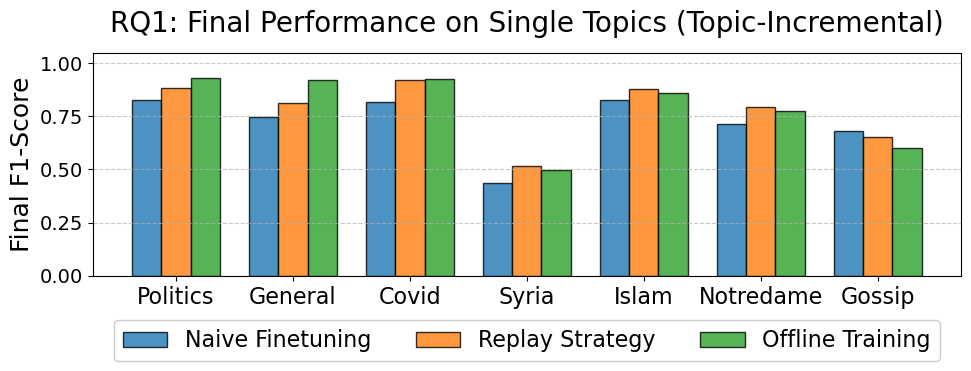

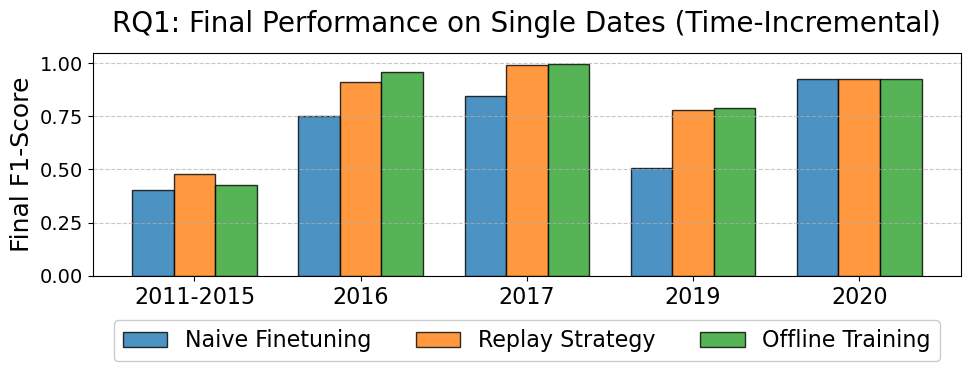

In [108]:
plot_rq1(type='topic')
plot_rq1(type='date')

## Results: RQ2

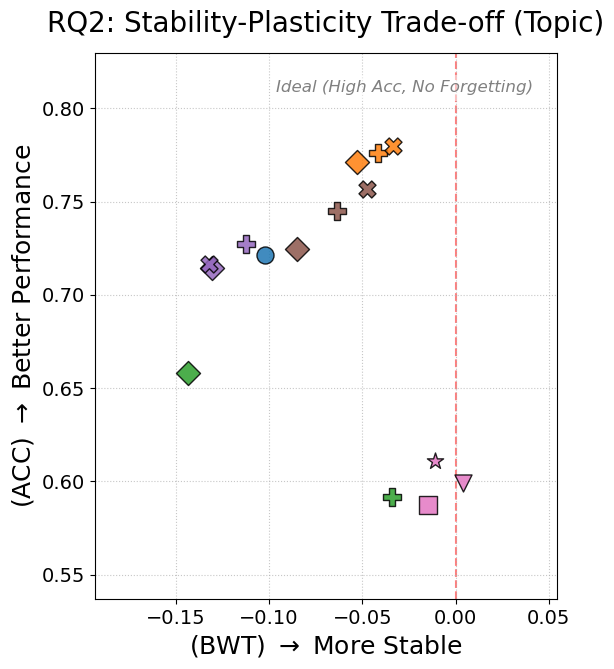

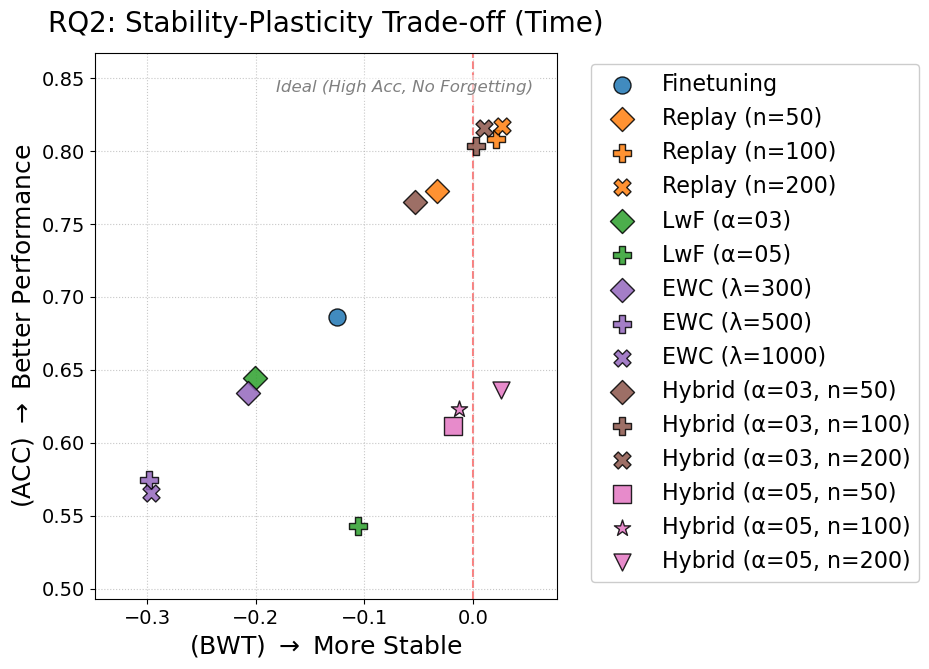

In [109]:
plot_rq2(type='topic')
plot_rq2(type='date')

## Results: RQ3

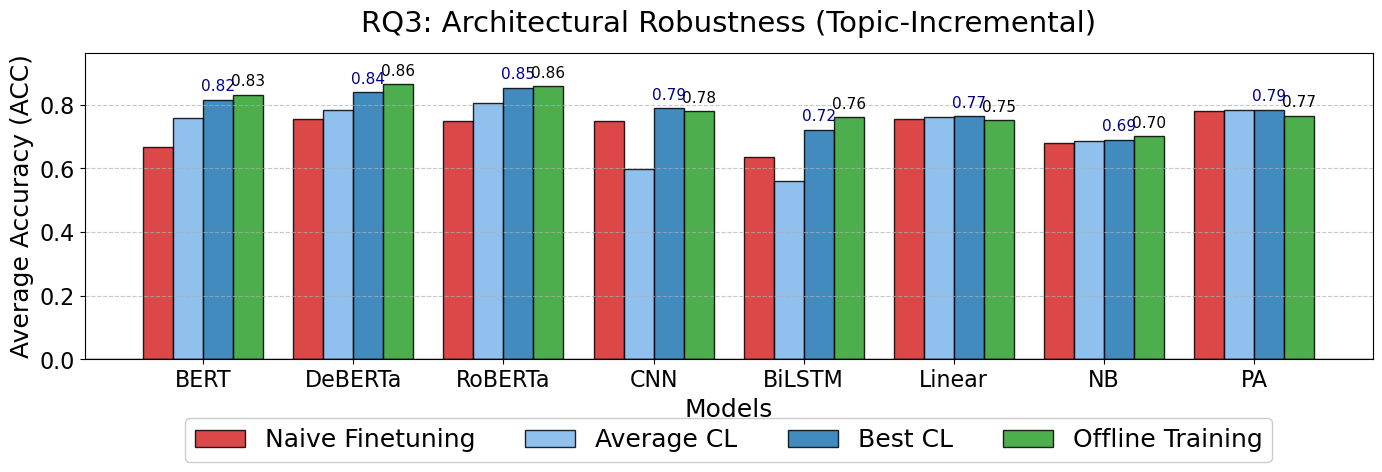

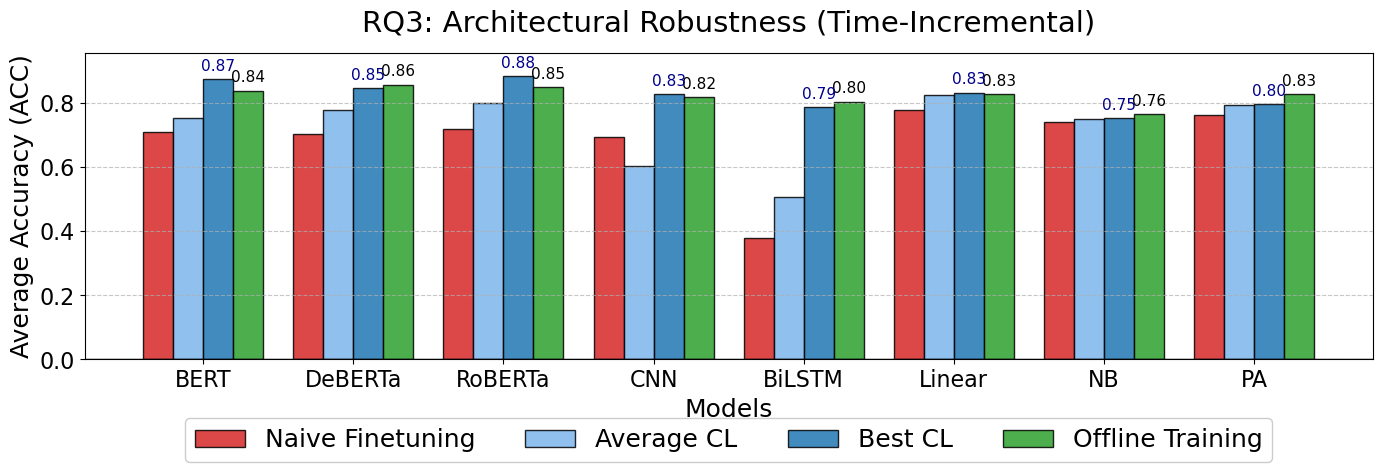

In [110]:
plot_rq3(type='topic')
plot_rq3(type='date')